# What drives the price of a car?

![](https://github.com/vegalopm/ml-assignment-mod11/blob/main/images/kurt.jpeg?raw=1)

**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

### Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary.

**Answer:** Build a Lasso model to predict the price of a used car with an MAE under $2K and identify the key features that drive the price of the car by extracting the top ranked non-zero coefficients.

### Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

**Answer:** The steps I will take to understand the data are the following:
1. Call `.info` on the DataFrame to see the column names and data types.
1. Call `.head()` on the DataFrame to see examples of the data in each column.
1. Identify any missing data or issues with the dataset provided that would require cleaning duraing the Data Preparation step.
1. Form hypothesis based on the first exploration of the data.
1. Plot some of the numeric features to observe their distribution.

In [1]:
# Defining all the imports in this cell
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LassoCV
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error,root_mean_squared_error
from sklearn.model_selection import train_test_split

import pandas as pd
import numpy as np
import seaborn as sns
import math

In [2]:
cars = pd.read_csv('data/vehicles.csv')
cars.info()
cars.head()

<class 'pandas.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  str    
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  str    
 5   model         421603 non-null  str    
 6   condition     252776 non-null  str    
 7   cylinders     249202 non-null  str    
 8   fuel          423867 non-null  str    
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  str    
 11  transmission  424324 non-null  str    
 12  VIN           265838 non-null  str    
 13  drive         296313 non-null  str    
 14  size          120519 non-null  str    
 15  type          334022 non-null  str    
 16  paint_color   296677 non-null  str    
 17  state         426880 non-null  str    
dtypes: float64(2), 

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
0,7222695916,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az
1,7218891961,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar
2,7221797935,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl
3,7222270760,worcester / central MA,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma
4,7210384030,greensboro,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc


In [3]:
# Find the possible values for certain columns
for col_name in ['state', 'condition', 'cylinders', 'fuel', 'title_status', 'transmission', 'drive', 'size', 'type', 'paint_color', 'year']:
    distinct_values = cars[col_name].unique()
    print(col_name, 'possible values: ', distinct_values)

state possible values:  <ArrowStringArray>
['az', 'ar', 'fl', 'ma', 'nc', 'ny', 'or', 'pa', 'tx', 'wa', 'wi', 'al', 'ak',
 'ca', 'co', 'ct', 'dc', 'de', 'ga', 'hi', 'id', 'il', 'in', 'ia', 'ks', 'ky',
 'la', 'me', 'md', 'mi', 'mn', 'ms', 'mo', 'mt', 'ne', 'nv', 'nj', 'nm', 'nh',
 'nd', 'oh', 'ok', 'ri', 'sc', 'sd', 'tn', 'ut', 'vt', 'va', 'wv', 'wy']
Length: 51, dtype: str
condition possible values:  <ArrowStringArray>
[nan, 'good', 'excellent', 'fair', 'like new', 'new', 'salvage']
Length: 7, dtype: str
cylinders possible values:  <ArrowStringArray>
[           nan,  '8 cylinders',  '6 cylinders',  '4 cylinders',
  '5 cylinders',        'other',  '3 cylinders', '10 cylinders',
 '12 cylinders']
Length: 9, dtype: str
fuel possible values:  <ArrowStringArray>
[nan, 'gas', 'other', 'diesel', 'hybrid', 'electric']
Length: 6, dtype: str
title_status possible values:  <ArrowStringArray>
[nan, 'clean', 'rebuilt', 'lien', 'salvage', 'missing', 'parts only']
Length: 7, dtype: str
transmission p

### 1. Analyzing the price distribution

In the next few cells I will be analyzing the distribution of car prices in the dataset.

In [4]:
# Output statistics on the price column
cars['price'].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

count    4.268800e+05
mean     7.519903e+04
std      1.218228e+07
min      0.000000e+00
10%      5.000000e+02
25%      5.900000e+03
50%      1.395000e+04
75%      2.648575e+04
90%      3.759000e+04
95%      4.450000e+04
99%      6.699500e+04
max      3.736929e+09
Name: price, dtype: float64

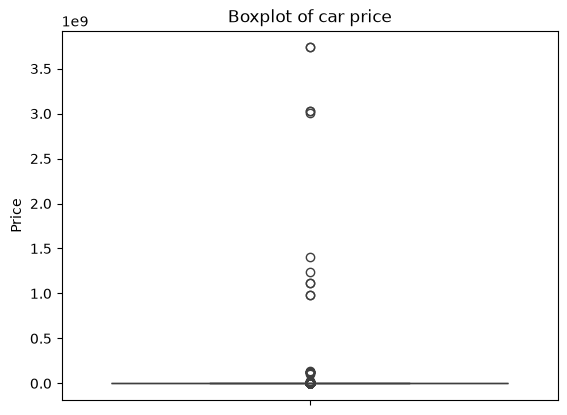

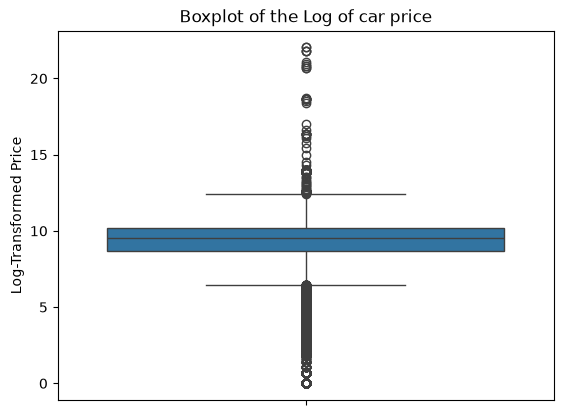

In [5]:
# Graph a box plot of the price column
sns.boxplot(y=cars['price'])
plt.title("Boxplot of car price")
plt.ylabel("Price")
plt.show()
sns.boxplot(y=np.log1p(cars['price']))
plt.ylabel("Log-Transformed Price")
plt.title("Boxplot of the Log of car price")
plt.show()

**Conclusion:** The price data is very skewed. Some data cleaning will be required.

### 2. Analyzing year column

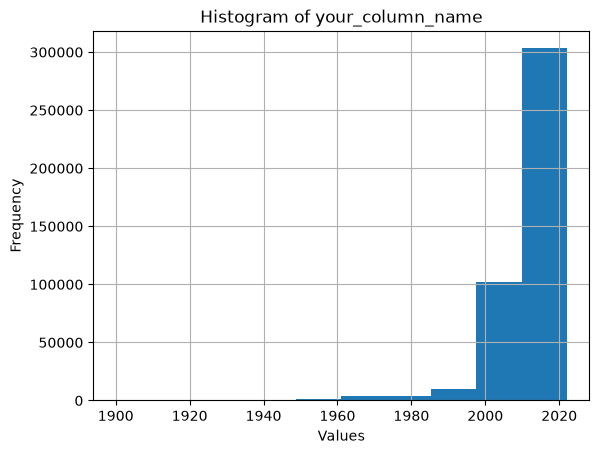

In [6]:
# A histogram of the number of cars per year
cars['year'].hist()
plt.title("Histogram of your_column_name")
plt.xlabel("Values")
plt.ylabel("Frequency")
plt.show()

**Conclusion:** The year is very skewed to the right. Some data cleanup might be needed.

### 3. Analyzing ordometer distribution

In [7]:
cars['odometer'].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

count    4.224800e+05
mean     9.804333e+04
std      2.138815e+05
min      0.000000e+00
10%      1.493900e+04
25%      3.770400e+04
50%      8.554800e+04
75%      1.335425e+05
90%      1.773771e+05
95%      2.040000e+05
99%      2.800000e+05
max      1.000000e+07
Name: odometer, dtype: float64

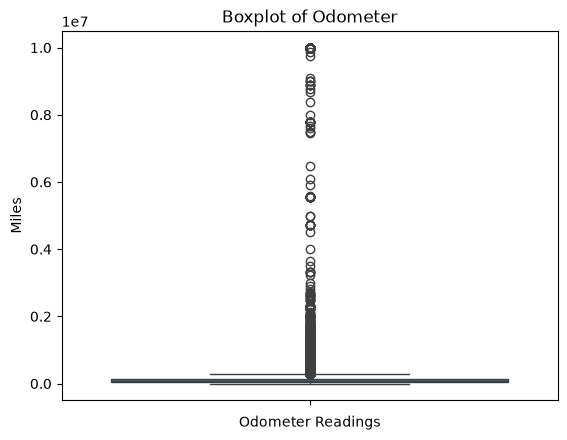

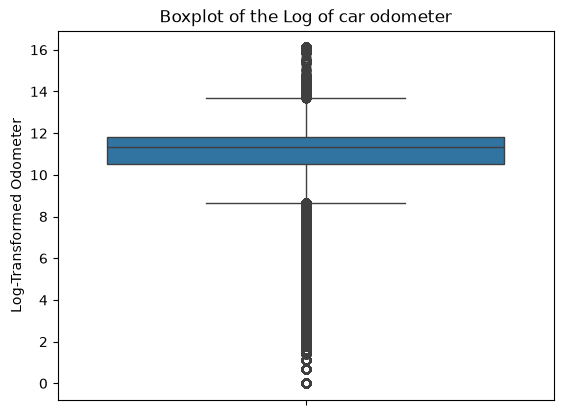

In [8]:
# A boxplot of odometer readings
sns.boxplot(y=cars['odometer'])
plt.title("Boxplot of Odometer")
plt.xlabel("Odometer Readings")
plt.ylabel("Miles")
plt.show()
sns.boxplot(y=np.log1p(cars['odometer']))
plt.ylabel("Log-Transformed Odometer")
plt.title("Boxplot of the Log of car odometer")
plt.show()

**Conclusion:** The odometer data is very skewed too. Some data cleaning is needed.

### Findings From Data Understanding

After analyzing the data, here are some conclusions I made:
1. I will drop `id` and `VIN` because these are just numbers to identify the vehicle that do not provide any significance to the price of the car.
1. I will drop `region` since it is too specific and it is somewhat redundant if `state` is present. **Update:** I ended up droping state too to reduce the number of features.
1. I will drop `model` since there are too many possible values for it and in reality a `model` is used by manufacturers to name a vehicle with a certain set of features such as `cylinders`, `fuel`, `drive`, among others. So, `model` becomes redundant.
1. When `year` is missing, I will fill it with the median `year`. **Update:** After creating a first iteration of the model, I decided I will use `year` to derive a new column `car_age` that is more representative of the value of a car and can be used to derived another important feature: `miles_per_year`.
1. I will fill null values of `odometer` with the median. **Update:** After creating a first iteration of the model, I decided I will use the log since it might be a better representation for the depreciation of the car. Also I will use `odometer` to derive the feature `miles_per_year` that also provides important information about the car.
1. I will not drop rows that contain at least one `Nan` column since there are columns (such as `cylinders`) that have a large number of `NaN` rows and keeping these rows would help more to also evaludate the importance of having a value in these features.
1. I will do 'one-hot' encoding of nonnumeric features.
1. **Update:** After doing a first model, the size feature was essentially zeroed by the model, so I'll be droping it.

### Data Preparation

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`.

### 1. Drop some columns and cleanup `odometer` and `year`

In [9]:
# Let's first drop the columns I don't need for the reasons mentioned above.
cars.drop(columns=['id', 'VIN', 'region', 'model', 'paint_color', 'size'], inplace=True)

# Now let's fill year with the median.
cars.loc[cars['year'].isna(), 'year'] = cars['year'].median()

# Now let's add the new column car_age. 2023 is used since the most recent car is from 2022.
cars['car_age'] = 2023 - cars['year']

# Now let's fill null values of odometer and add the new column log_odometer
cars.loc[cars['odometer'].isna(), 'odometer'] = cars['odometer'].median()
cars['log_odometer'] = np.log1p(cars['odometer'])

# Now let's calculate the log_miles_per_year column
cars['log_miles_per_year'] = np.log1p(cars['odometer'] / cars['car_age'])

# Let's drop the columns year and odometer now that they are not needed
cars.drop(columns=['year', 'odometer'], inplace=True)

# Let's keep cars whose title is 'clean' or 'rebuilt'
cars = cars.loc[(cars['title_status'] == 'clean') | (cars['title_status'] == 'rebuilt')]

cars.info()
cars.head()

<class 'pandas.DataFrame'>
Index: 412336 entries, 27 to 426879
Data columns (total 13 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   price               412336 non-null  int64  
 1   manufacturer        395638 non-null  str    
 2   condition           242843 non-null  str    
 3   cylinders           238196 non-null  str    
 4   fuel                410547 non-null  str    
 5   title_status        412336 non-null  str    
 6   transmission        410464 non-null  str    
 7   drive               288047 non-null  str    
 8   type                322812 non-null  str    
 9   state               412336 non-null  str    
 10  car_age             412336 non-null  float64
 11  log_odometer        412336 non-null  float64
 12  log_miles_per_year  412336 non-null  float64
dtypes: float64(3), int64(1), str(9)
memory usage: 60.3 MB


,price,manufacturer,condition,cylinders,fuel,title_status,transmission,drive,type,state,car_age,log_odometer,log_miles_per_year
27,33590,gmc,good,8 cylinders,gas,clean,other,NaN,pickup,al,9.0,10.966887,8.769801
28,22590,chevrolet,good,8 cylinders,gas,clean,other,NaN,pickup,al,13.0,11.173669,8.608888
29,39590,chevrolet,good,8 cylinders,gas,clean,other,NaN,pickup,al,3.0,9.860632,8.762124
30,30990,toyota,good,8 cylinders,gas,clean,other,NaN,pickup,al,6.0,10.624371,8.832734
31,15000,ford,excellent,6 cylinders,gas,clean,automatic,rwd,truck,al,10.0,11.759793,9.457279


### 2. Remove `price` outliers

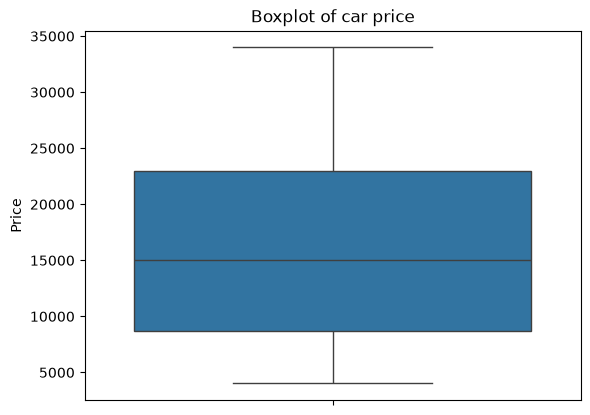

In [10]:
# Keeping higher than 4,000 and lower than 34,000
cars = cars.loc[(cars['price'] > 4_000) & (cars['price'] < 34_000)]
# Graph a box plot of the price column to see the new distribution
sns.boxplot(y=cars['price'])
plt.title("Boxplot of car price")
plt.ylabel("Price")
plt.show()

In [11]:
cars['price'].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

count    278397.000000
mean      16284.551741
std        8551.897325
min        4027.000000
10%        5995.000000
25%        8700.000000
50%       14995.000000
75%       22995.000000
90%       29500.000000
95%       31590.000000
99%       33880.000000
max       33999.000000
Name: price, dtype: float64

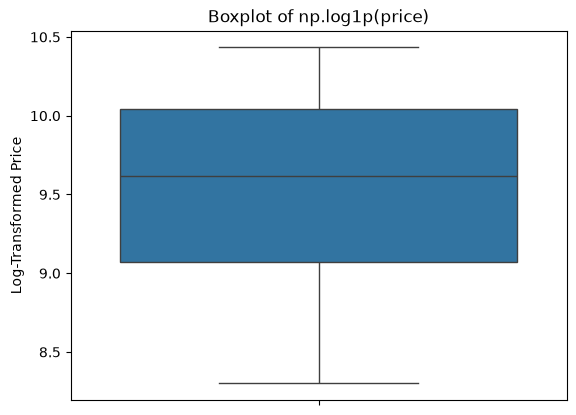

In [12]:
sns.boxplot(y=np.log1p(cars['price']))
plt.title("Boxplot of np.log1p(price)")
plt.ylabel("Log-Transformed Price")
plt.show()

The price distribution looks much better. The log still shows some outliers, so it's something to consider to come back if the model needs improvements.

### 3. Remove `odometer` outliers

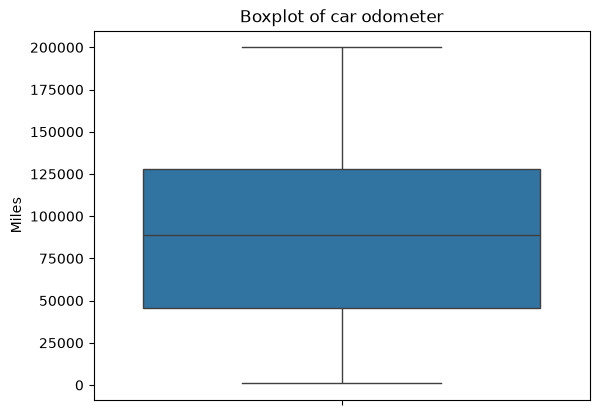

In [13]:
# Let's keep values in the odometer between 1,000 and 200,000 miles
cars = cars.loc[(cars['log_odometer'] > np.log1p(1_000)) & (cars['log_odometer'] < np.log1p(200_000))]
# Graph a box plot of the price column to see the new distribution
sns.boxplot(y=np.expm1(cars['log_odometer']))
plt.title("Boxplot of car odometer")
plt.ylabel("Miles")
plt.show()

### 4. Remove `year` outliers

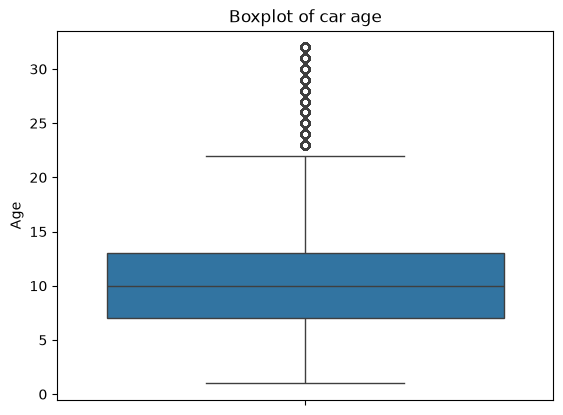

<class 'pandas.DataFrame'>
Index: 253089 entries, 27 to 426879
Data columns (total 13 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   price               253089 non-null  int64  
 1   manufacturer        246306 non-null  str    
 2   condition           157562 non-null  str    
 3   cylinders           146582 non-null  str    
 4   fuel                251759 non-null  str    
 5   title_status        253089 non-null  str    
 6   transmission        252049 non-null  str    
 7   drive               179395 non-null  str    
 8   type                204848 non-null  str    
 9   state               253089 non-null  str    
 10  car_age             253089 non-null  float64
 11  log_odometer        253089 non-null  float64
 12  log_miles_per_year  253089 non-null  float64
dtypes: float64(3), int64(1), str(9)
memory usage: 37.1 MB


In [14]:
# Let's keep cars from year 1990 and above
cars = cars.loc[cars['car_age'] <= 32]
# Graph a box plot of the price column to see the new distribution
sns.boxplot(y=cars['car_age'])
plt.title("Boxplot of car age")
plt.ylabel("Age")
plt.show()

cars.info()

### Modeling

With your (almost?) final dataset in hand, it is now time to build some models.  Here, you should build a number of different regression models with the price as the target.  In building your models, you should explore different parameters and be sure to cross-validate your findings.

In [15]:
cars_y = cars['price']
cars_X = cars.drop(columns=['price'])
cars_X_train, cars_X_test, cars_y_train, cars_y_test = train_test_split(cars_X, cars_y, test_size=0.3, random_state=42)

In [16]:
# Have separate pipelines for numeric features and nonnumeric features
numeric_features = ['car_age', 'log_odometer', 'log_miles_per_year']
nonnumeric_features = ['manufacturer', 'condition', 'cylinders', 'fuel', 'transmission', 'drive', 'type', 'title_status', 'state']

# Build numeric features pipeline
cars_numeric_pipe = Pipeline([
    ('polyfeatures', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler())
])

# Build nonnumeric features pipeline
cars_nonnumeric_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(drop='if_binary', min_frequency=0.01,handle_unknown='infrequent_if_exist'))
])

preprocessor = ColumnTransformer([
    ('numeric', cars_numeric_pipe, numeric_features),
    ('nonnumeric', cars_nonnumeric_pipe, nonnumeric_features)
])

cars_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('lasso', LassoCV(cv=5, max_iter=20000, tol=1e-3, eps=1e-2, random_state=42, selection='random'))
])

cars_y_train_log = np.log1p(cars_y_train)
cars_pipe.fit(cars_X_train, cars_y_train_log)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('lasso', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['manufacturer','condition','cylinders',...,'car_age','log_odometer', 'log_miles_per_year']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('nonnumeric', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed 

In [17]:
train_preds_log = cars_pipe.predict(cars_X_train)
test_preds_log = cars_pipe.predict(cars_X_test)
lasso_train_rmse = root_mean_squared_error(cars_y_train, np.expm1(train_preds_log))
lasso_test_rmse = root_mean_squared_error(cars_y_test, np.expm1(test_preds_log))
test_mae = mean_absolute_error(cars_y_test, np.expm1(test_preds_log))
test_mape = mean_absolute_percentage_error(cars_y_test, np.expm1(test_preds_log))

print("Train RMSE:  $", f"{lasso_train_rmse:,.2f}")
print("Test RMSE:  $", f"{lasso_test_rmse:,.2f}")
print("Test MAE:   $", f"{test_mae:,.2f}")
print("Test MAPE:  ", f"{test_mape:.2%}")

Train RMSE:  $ 5,304.84
Test RMSE:  $ 5,268.51
Test MAE:   $ 3,887.85
Test MAPE:   26.49%


In [18]:
feature_names = cars_pipe.named_steps['preprocessor'].get_feature_names_out()
lasso_coefs = cars_pipe.named_steps['lasso'].coef_
lasso_df = pd.DataFrame({
    'feature': feature_names,
    'coef': lasso_coefs
})

lasso_df.loc[lasso_df['coef'] != 0]

,feature,coef
3,numeric__car_age^2,0.195921
5,numeric__car_age log_miles_per_year,-0.566906
7,numeric__log_odometer log_miles_per_year,-0.027646
8,numeric__log_miles_per_year^2,-0.020147
11,nonnumeric__manufacturer_bmw,0.020688
16,nonnumeric__manufacturer_dodge,-0.006737
20,nonnumeric__manufacturer_hyundai,-0.042432
23,nonnumeric__manufacturer_kia,-0.051912
24,nonnumeric__manufacturer_lexus,0.125755
27,nonnumeric__manufacturer_mercedes-benz,0.017043


### Evaluation

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

**Answer:** I had some issues on building a first model. I kept getting "Objective did not converge" errors, so I started tweaking the pipeline and the parameters to the LassoCV method. I went back to Data Understanding and looked for outliers in price. I removed outliers from price, and fit with the log of the price. With those changes I was able to get a first model.

#### First model
The first model I created took very long to train and it had a train RMSE of \\$9,414 and a test RMSE of \\$9,488. With these values being too high, I decided I needed to adjust even further.

#### Second model
For the second model I changed the limits of the price from between \\$5K and \\$100K to limits of \\$4K and \\$34K. This new model had a train RMSE of \\$6,030, a test RMSE of \\$6,024, a test MAE of \\$4,545 and MAPE of 33.7\%. Great progress, but still far from the goal of \\$2K MAE.

#### Final model
I had noticed the skew in `year` and `odometer`, but didn't do much about it. I decided to change the features and instead of using `year` I decided to derive `car_age` since that's a smaller scale and it tells a lot about the car. I also decided to only keep cars from 1990 and above to reduce the skew. For `odometer` I decided to remove outliers and keep it between 1K and 200K miles. I also decided to instead use the log of `odometer` for training, since the numbers are big. I also decided to add one more feature based on the `car_age` and the `odometer`, which is miles per year. This feature tells us more information about the car usage and has an effect on the car price.

This last model had a train RMSE of \\$5,304.84, a test RMSE of \\$5,268.51, a test MAE of \\$3,887.85 and a test MAPE of 26.49\%. It is still not the goal of a MAE of \\$2K, but it's not that far from it. Most likely to improve these numbers I need to use a different method than Lasso that I haven't learned.

### Deployment

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.

### Conclusions

Based on the analysis made on cars made between 1990 and 2022, with a range price of \\$4K and \\$34K and a odemeter reading between 1K miles and 200K miles, these are the factors make a car more or less expensive:

* Positive Value Drivers
  * Diesel fuel: It showed as the highest factor that increases the car's price with a coefficient of 0.31.
  * 8-cylinder Engine: It is the second highest factor with a coefficient of 0.17.
  * Pickups and Trucks: With a coefficient of 0.15, these are the third highest factor.
  * Brands: Lexus with a coefficient of 0.12 and Toyota with 0.06, these show as important factors for the car's price.
* Negative Value Drivers
  * Age × Mileage Compound Depreciation: It's the most significant negative term with -0.567.
  * Front-Wheel Drive: This is the second most penalized characteristic with a coefficient of -0.242.
  * 4-Cylinder Engines: with a coefficient of -0.181, this is the third most negative term.
  * Body Styles: Hatchbacks and Sedans with coefficients of -0.11 and -0.09 respectively are on the top of significant negative terms.
  * Brands: Some brands like Nissan (-0.102), Kia (-0.052) and Hyundai (-0.042) are shown as factors that drive down the price of the car.

##### Recommendations
* Prioritize obtaining Pickups and Trucks since the three highest characterics that increase the price of the car are related to these type of cars.
* Prioritize obtaining cars from Lexus or Toyota since these show as positive drivers for the price of a car.
* Avoid older vehicles with high mileage since it is an exponential value loss.
* Avoid cars with 4-Cylinders since it is one of the most penalized characteristics.

